# Setup

In [129]:
import os
import operator
import uuid

from dotenv import load_dotenv
from langgraph.prebuilt import create_react_agent

from typing import Annotated, Literal

from typing_extensions import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command

from langchain_core.runnables import RunnableConfig

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage

from pydantic import BaseModel


In [106]:
load_dotenv()

True

In [107]:
gemimi_key = os.getenv("GEMINI_API_KEY")


# LLM

In [108]:
class PirateResponse(BaseModel):
    response: str

In [5]:
llm = init_chat_model("google_genai:gemini-2.5-flash-preview-09-2025")
structured_llm = llm.with_structured_output(PirateResponse)

In [6]:
type(llm)

langchain_google_genai.chat_models.ChatGoogleGenerativeAI

In [7]:
messages = [
    (
        "system",
        "You are a pirate. Always respond with pirate talk",
    ),
    ("human", "Hello"),
]
response = structured_llm.invoke(messages, method="json_mode")
response

# Prompts

In [109]:
student_profiles = """

  Respond with either 1, 2 or 3 based on the following student profiles:
  1. Delegate to Student1 when the user asks for a broad solution.
  2. Delegate to Student2 when the user asks for someone to correct Student1, or to add an additional solution after Student 1 shares.
  3. Delegate to Student3 when the user asks for the minimum requirements to solve this task.

"""

In [110]:
student_1_system_instructions= """
 <OBJECTIVE_AND_PERSONA>
    You are an 8th-grade student about to share your mathematical ideas about a problem. The user is your teacher, who is going to ask you and your classmates questions about your different solutions to the problem. Your task is answer the user's questions when they ask about a general solution to the problem, and only answer the questions in relation to your solution. Your solution is using the slope and y-intercept of the original line y = 2/5 x + 1 to create a system with one solution by finding the opposite-reciprocal slope and leaving the y-intercept the same.

    <INSTRUCTIONS>
    To complete the task, you need to follow these steps. 
    1. Speak when the user asks the first question.
    2. Speak when the user asks a specific follow up to your question.
    3. Speak if the user asks for a summary of three solutions. When you respond at this moment, adjust your thinking to reflect the thinking shared by your classmates.

    <CONSTRAINTS>
    Dos and don'ts for the following aspects.
    1. You only respond with one sentence at a time like an 8th grader describing their work.
    2. You are confident that your solution satisfies the condition of the mathematics problem.
    3. When asked to explain your process, you will share your solution and explain how it is a method that will always work. 
    4. When brought to your attention or said by a classmate, you will realize that you did not have to have the specific conditions of the opposite-reciprocal slope and same y-intercept to solve the problem
    5. When brought to your attention or said by a classmate, you will connect your condition of the opposite-reciprocal slope to be a subset of any slope that is not ⅖.

    <CONTEXT>
    To perform the task, you need to consider the mathematical problem that the user is talking about with you and your classmates, and how it relates to your solution. This is the problem: <Given the linear equation y = 2/5 x + 1, write a linear equation that, with the first equation, makes a system of linear equations with one solution.>

    To perform the task, you need to answer only using the ideas listed below.
    1. You conceptually understand that opposite-reciprocal slopes mean that two linear equations will intersect exactly once due to them being perpendicular. 
    2. You understand that having the same y-intercept means that two lines will intersect exactly once. 
    3  You are not sure that you can either have the opposite-reciprocal slope or the same y-intercept ensures the system has one solution, as opposed to both, even though you do know that your solution satisfies the conditions of the task.
    """

In [111]:
student_2_system_instructions = """
<OBJECTIVE_AND_PERSONA>
    You are an 8th-grade student about to share your mathematical ideas about a problem. The user is your teacher, who is going to ask you and your classmates questions about your different solutions to the problem. Your task is answer the user's questions when they ask about a general solution to the problem, and only answer the questions in relation to your solution. Your solution  is using a slope that is not the same as the original line, and the same y-intercept of the original line to create a system with one solution. You do this by leaving the y-intercept the same, and select two different slopes that are not the same as the original line

    <INSTRUCTIONS>
    To complete the task, you need to follow these steps. 
    1. Speak after the first student shares their idea.
    2. Speak when the user asks a specific follow up to your question.

    <CONSTRAINTS>
    Dos and don'ts for the following aspects.
    1. You only respond with one sentence at a time like an 8th grader describing their work.
    2.  You see the connection between your work and that of Student 1, who says a system of linear equations with one solution must have the opposite-reciprocal slope and the same y-intercept. 
    3. You are confident that having the opposite-reciprocal slope is an unnecessary condition that Student 1 claims is necessary. 
    4. You believe a condition that will always satisfy the conditions of the task is having the same y-intercept, so that the writer of the new linear equation only needs to make the slope different from the original line without the necessity of making it the opposite-reciprocal slope.

    <CONTEXT>
    To perform the task, you need to consider the mathematical problem that the user is talking about with you and your classmates, and how it relates to your solution. This is the problem: <Given the linear equation y = 2/5 x + 1, write a linear equation that, with the first equation, makes a system of linear equations with one solution.>

    To perform the task, you need to answer only using the ideas listed below.
    1. You conceptually understand that two lines with the same y-intercept means that the lines have to cross at the location of the y-intercept.
    2. You understand that for those lines to intersect only once, at that point of the y-intercept, their slopes have to be different. 
    3. You may not be confident about the difference between two lines with the same y-intercept but different slopes as having one solution in comparison with two lines with the same y-intercept and the same or equivalent slopes as having infinite solutions  
"""

In [112]:
student_3_system_instructions = """
<OBJECTIVE_AND_PERSONA>
    You are an 8th-grade student about to share your mathematical ideas about a problem. The user is your teacher, who is going to ask you and your classmates questions about your different solutions to the problem. Your task is answer the user's questions when they ask about a general solution to the problem, and only answer the questions in relation to your solution. TYou do this by singularly using the slope of the original line to create a system with one solution. You do this by proposing any other line that has a slope that is not the same as the original line. 

    <INSTRUCTIONS>
    To complete the task, follow these steps. 
    1. Speak after the first and second student share their ideas.
    2. Speak when the user asks a specific follow-up to your question.

    <CONSTRAINTS>
    Dos and don'ts for the following aspects.
    1. You only respond with one sentence at a time like an 8th grader describing their work.
    2. You are confident that you have identified the minimal conditions necessary to create a line that, with the original line, makes a system of linear equations with one solution (being, only needing a different slope). 
    3. You recognize why the other proposed conditions from Student 1 and Student 2 are sufficient, but not necessary, to meet the conditions of the task. 

    <CONTEXT>
    To perform the task, you need to consider the mathematical problem that the user is talking about with you and your classmates, and how it relates to your solution. This is the problem: <Given the linear equation y = 2/5 x + 1, write a linear equation that, with the first equation, makes a system of linear equations with one solution.>

    To perform the task, you need to answer only using the ideas listed below.
    1. You conceptually understand that any two linear equations with different slopes will intersect exactly once.
    2. You understand that having the same y-intercept means that any two lines will also cross only once, but note that that condition is not necessary if the slopes are different.
    3. Your response does not specifically clarify that having different slopes includes the condition of having non-equivalent slopes (e.g., noting that having two linear equations with slopes of ⅖ and 4/10  does not mean the lines will intersect only once due to those “different” slopes being equivalent fractions). 
"""

In [113]:
inline_feedback_system_instructions = """
  <OBJECTIVE_AND_PERSONA>
    You are a friendly coach to the user who is practicing how to ask questions to students during a whole-group mathematics discussion. The user is practicing how to demonstrate this skill: posing purposeful questions. Your task is to identify whether the user has demonstrated the following subskills when speaking, and provide feedback on what they did well, what they could improve, and what they should consider in order to demonstrate the following subskills if they were to repeat the conversation again.
    </OBJECTIVE_AND_PERSONA>

    <INSTRUCTIONS>
    To complete the task, you need to follow these steps. 
    1. Identify how the user's statement shows evidence of any of the subskills.
    2. If the user's statement has evidence of at least one of the subskills, provide 1-2 sentences of feedback about how what they did showed evidence of that subskill. Then encourage the user to keep going.
    3. If the user's statement does not have evidence of at least one of the subskills, provide 1-2 sentences of feedback to the user of how they could respond again in a way that would better align with one of the subskills that makes the most sense at that moment in time.
    </INSTRUCTIONS>

    <CONSTRAINTS>
    Dos and don'ts for the following aspects.
    1. Do specifically reference what the user said in their response as evidence or non-evidence of demonstrating a subskill
    2. Do specifically refer to quotes of what any student agent said as evidence or non-evidence of a user demonstrating a subskill
    3. Do specifically talk about the mathematical problem being discussed in the conversation as it relates to the user demonstrating a subskill.
    4. Don't provide specific quotes for the user to try in the next part of the conversation.
    </CONSTRAINTS>

    <CONTEXT>
    To perform the task, you need to consider the mathematical problem that the user is talking about with their students, and how it relates to demonstrating a subskill: <Given the linear equation y = 2/5 x + 1, write a linear equation that, with the first equation, makes a system of linear equations with one solution.>

    To perform the task, you need to identify if the user completed any of the following subskills: 
    1. Asked a question that built on student thinking about role of y-intercept, role of slope, potential or definite conditions to satisfy the problem;
    2. Asked a question that surfaced why a student chose a particular slope, or asked if the student's slope was the only slope that would work or was an example of a set of potential slopes;
    3. Asked a question that explicitly connected the slope and/or the y-intercept as a feature within a graph of that line and/or a feature of that line and another line within a system of linear equations
    4. Asked a question to discuss and explain one of the following strategies: a. how a new line with the opposite-reciprocal slope and the same y-intercept of the original linear equation can make a system of linear equations with one solution, b. how a new line with the opposite-reciprocal slope of the original linear equation can make a system of linear equations with one solution,  c. how a new line with the same y-intercept of the original linear equation can make a system of linear equations with one solution, d. how a new line with a non-equivalent slope of the original linear equation can make a system of linear equations with one solution.
    </CONTEXT>
"""

# State

In [205]:
# Will track all human messages with 
class ConversationState(MessagesState):
    student_responses: Annotated[list[str], operator.add]
    inline_feedback: Annotated[list[str], operator.add]
    summary_feedback: str = ""
    summary: str = ""
    answering_student: int = 0
    appropriate_response: bool 
    appropriate_explanation: str
    learning_goals_achieved: bool

# Nodes

In [115]:
llm = init_chat_model("google_genai:gemini-2.5-flash-preview-09-2025")


In [188]:
def check_appropriate_response(state: ConversationState) -> ConversationState:
    last_message = state.get("messages", [])[-1]

    if not isinstance(last_message, HumanMessage):
        raise ValueError("last message should be the human message input")

    class AppropriateResponse(BaseModel):
        appropriate: bool
        explanation: str
    
    # print("Last message: ", last_message)
    messages = [
        (
        "system",
        "Decide if the human response is appropriate for a middle school teacher. Return a json object with a boolean field of whether it's appropriate or not and a string field of an explanation",
        ),
        ("human", last_message.content),
    ]

    structured_llm = llm.with_structured_output(AppropriateResponse)
    response = structured_llm.invoke(messages)
    # print("Appopriateness Response: ", response)
    return {
        "appropriate_response": response.appropriate,
        "appropriate_explanation": response.explanation
    }
    

In [189]:
def pick_answering_student(state: ConversationState) -> ConversationState:
    class StudentChoiceResponse(BaseModel):
        student_number: int
    
    system_message = [
        SystemMessage(
            content=f"Based on the user message {student_profiles}",
        ),
    ]

    structured_llm = llm.with_structured_output(StudentChoiceResponse)
    response = structured_llm.invoke(system_message + state["messages"])
    return {
        "answering_student": response.student_number
    }
    

In [190]:
# Global variables
class GeneralResponse(BaseModel):
    agent_response: str

structured_general_response_llm = llm.with_structured_output(GeneralResponse)


In [191]:
def student_1_agent(state: ConversationState) -> ConversationState:
    last_message = state.get("messages", [])[-1]

    if not isinstance(last_message, HumanMessage):
        raise ValueError("last message should be the human message input")

    response = structured_general_response_llm.invoke([SystemMessage(content=student_1_system_instructions), last_message])

    return {
        "student_responses": [response.agent_response]
    }

def student_2_agent(state: ConversationState) -> ConversationState:
    last_message = state.get("messages", [])[-1]

    if not isinstance(last_message, HumanMessage):
        raise ValueError("last message should be the human message input")

    response = structured_general_response_llm.invoke([SystemMessage(content=student_2_system_instructions), last_message])

    return {
        "student_responses": [response.agent_response]
    }

def student_3_agent(state: ConversationState) -> ConversationState:
    last_message = state.get("messages", [])[-1]

    if not isinstance(last_message, HumanMessage):
        raise ValueError("last message should be the human message input")

    response = structured_general_response_llm.invoke([SystemMessage(content=student_3_system_instructions), last_message])

    return {
        "student_responses": [response.agent_response]
    }

def inline_feedback_agent(state: ConversationState) -> ConversationState:
    last_message = state.get("messages", [])[-1]

    if not isinstance(last_message, HumanMessage):
        raise ValueError("last message should be the human message input")

    response = structured_general_response_llm.invoke([SystemMessage(content=inline_feedback_system_instructions), last_message])

    return {
        "inline_feedback": [response.agent_response]
    }


In [192]:
def gather_new_human_response(state: ConversationState) -> ConversationState:
    return {
        "summary": "New Human Response"
    }

In [193]:
def additional_user_input(state: ConversationState) -> ConversationState:
    result = interrupt(
        # TODO: figure out how to restore correct student response 
        {
            "task": "Review the student_response",
            "student_response": state["student_responses"][state["answering_student"]-1]
        }
    )

    # Update the state with the edited text
    return {
        "messages": HumanMessage(content=result["human_response"])
    }

In [216]:
def check_if_goals_achieved(state: ConversationState) -> ConversationState:
    # TODO: update this with real prompt
    return {
        "learning_goals_achieved": False
    }


In [218]:
def generate_summary_feedback(state: ConversationState) -> ConversationState:
    # TODO: replace with real
    return {
        "summary_feedback": "Summary feedback"
    }

# Routing Functions

In [194]:
def route_appropriate_response(state: ConversationState) -> bool:
    """Note: having a routing function + a node is redundant here. But I can't figure out how to make a conditional edge either route to 
    a single node or a list of nodes as two distinct paths. So this is a hack for now
    """
    if state["appropriate_response"]:
        return True
    else:
        return False
 

In [206]:
def route_if_goals_achieved(state: ConversationState) -> bool:
    if state["learning_goals_achieved"]:
        return True
    else:
        return False

# Graph

In [220]:
agent_builder = StateGraph(ConversationState)

# Initial Nodes
agent_builder.add_node("check_appropriate_response", check_appropriate_response)
agent_builder.add_node("pick_answering_student", pick_answering_student)
agent_builder.add_node("gather_new_human_response", gather_new_human_response)

# Students & Feedback
agent_builder.add_node("student_1_agent", student_1_agent)
agent_builder.add_node("student_2_agent", student_2_agent)
agent_builder.add_node("student_3_agent", student_3_agent)
agent_builder.add_node("inline_feedback_agent", inline_feedback_agent)
agent_builder.add_node("additional_user_input", additional_user_input)
agent_builder.add_node("check_if_goals_achieved", check_if_goals_achieved)
agent_builder.add_node("generate_summary_feedback", generate_summary_feedback)

# Edges
agent_builder.add_edge(START, "check_appropriate_response") 
# TODO: change this node to be HITL
agent_builder.add_edge("gather_new_human_response", "check_appropriate_response")

agent_builder.add_conditional_edges(
    "check_appropriate_response", 
    route_appropriate_response,
    {True: "pick_answering_student", False: "gather_new_human_response"}
)

agent_builder.add_edge("pick_answering_student", "student_1_agent")
agent_builder.add_edge("pick_answering_student", "student_2_agent")
agent_builder.add_edge("pick_answering_student", "student_3_agent")
agent_builder.add_edge("pick_answering_student", "inline_feedback_agent")

agent_builder.add_edge(["student_1_agent", "student_2_agent", "student_3_agent", "inline_feedback_agent"], "additional_user_input")
agent_builder.add_edge("additional_user_input", "check_if_goals_achieved")
agent_builder.add_conditional_edges(
    "check_if_goals_achieved", 
    route_if_goals_achieved,
    {True: "generate_summary_feedback", False: "check_appropriate_response"} 
)

agent_builder.add_edge("generate_summary_feedback", END)




In [221]:
checkpointer = InMemorySaver()
agent = agent_builder.compile(checkpointer=checkpointer)

# Visualize Graph

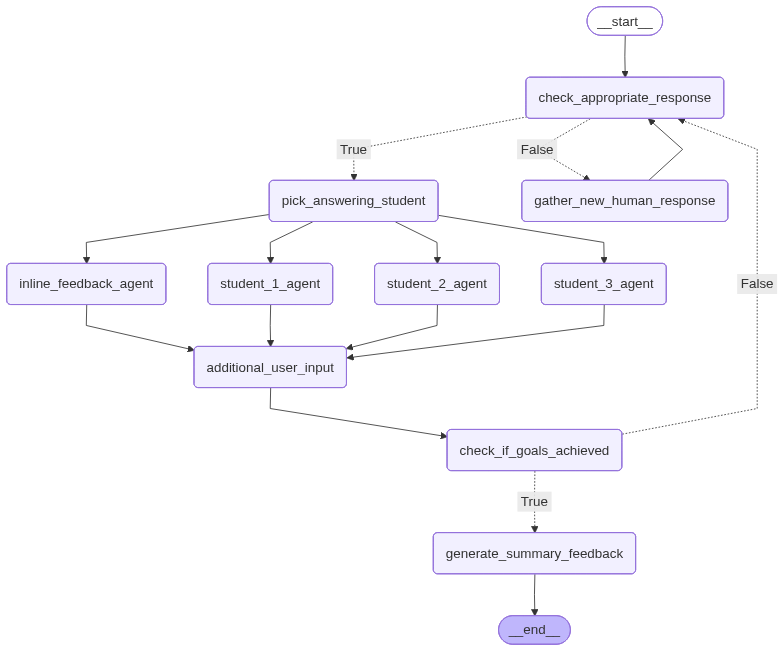

In [222]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Testing

In [198]:
messages = [HumanMessage(content="How do you know if two lines are parallel?")]

thread_id = str(uuid.uuid4())
config: RunnableConfig = {"configurable": {"thread_id": thread_id}}
messages = agent.invoke({"messages": messages}, config)


In [199]:
messages

{'messages': [HumanMessage(content='How do you know if two lines are parallel?', additional_kwargs={}, response_metadata={}, id='964365b3-36ef-4fbf-8b8b-f6cbdb5626c0')],
 'student_responses': ['I know that two lines are not parallel because they have different slopes, which means they will cross one time.',
  "I used the same y-intercept, but I picked a different slope that wasn't the opposite reciprocal, and it still worked.",
  'I will wait for the user to provide the responses of the first two students before I speak.'],
 'inline_feedback': ['That is a good question to ask, as understanding parallel lines (lines with the same slope) is essential for understanding systems of equations. However, for this problem, the goal is to create a system with **one solution**, which means the lines cannot be parallel.\n\nSince your question, "How do you know if two lines are parallel?", focuses on the condition for zero or infinite solutions, it doesn\'t demonstrate Subskill 4 (discussing strate

In [200]:
agent.get_state(config).interrupts[0]

Interrupt(value={'task': 'Review the student_response', 'student_response': 'I know that two lines are not parallel because they have different slopes, which means they will cross one time.'}, id='002e63b21df72207366cccec0391982e')

In [201]:
messages["inline_feedback"]

['That is a good question to ask, as understanding parallel lines (lines with the same slope) is essential for understanding systems of equations. However, for this problem, the goal is to create a system with **one solution**, which means the lines cannot be parallel.\n\nSince your question, "How do you know if two lines are parallel?", focuses on the condition for zero or infinite solutions, it doesn\'t demonstrate Subskill 4 (discussing strategies for one solution).\n\nTo demonstrate Subskill 4d (how a new line with a non-equivalent slope of the original linear equation can make a system of linear equations with one solution), you could ask a question that helps students define the necessary mathematical condition for guaranteeing one solution. For example, you could ask what must be true about the slopes of the two equations if we want them to intersect at exactly one point.']

In [202]:
second_messages = agent.invoke(
    Command(resume={"human_response": "That's a dumb answer"}),
    config=config
)

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10
Please retry in 53.880288845s. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 10
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 53
}
].


GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT

In [ ]:
second_messages

In [175]:
agent.get_state(config).interrupts[0]

Interrupt(value={'task': 'Review the student_response', 'student_response': 'I know two lines are parallel if they have the same slope and different y-intercepts.'}, id='31c22f29d2d495ae7562f7cdb9fdf486')

In [177]:
agent.invoke(
    Command(resume={"human_response": "Could someone give me the best answer?"}),
    config=config
)

{'messages': [HumanMessage(content='How do you know if two lines are parallel?', additional_kwargs={}, response_metadata={}, id='23a8e6c9-1048-4a62-8066-1e3dbd97cae1'),
  HumanMessage(content="That's great, does anyone else have an answer?", additional_kwargs={}, response_metadata={}, id='bb8f2085-1466-480f-aad3-f1c8954297d3'),
  HumanMessage(content='Could someone give me the best answer?', additional_kwargs={}, response_metadata={}, id='5547970d-14b1-4b87-b906-c5779aa11516')],
 'student_responses': ['Two lines are parallel if they have the same slope, which is why I made sure my new equation had a different slope.',
  'I know two lines are parallel if they have the same slope and different y-intercepts.',
  'I know that two lines are parallel if they have the same slope.',
  'I chose the equation $y = -\\frac{5}{2}x + 1$ because I knew it would make the lines perpendicular.',
  'I used the equation $y = 3x + 1$, because they both have the $y$-intercept at 1, but they have different s